In [1]:
import PerceptualWavesStimulus as PWstim
import PerceptualWavesAuxillaryFunctions as PWAux
import BinocularRivalryWavesORGaNICs_vers1 as BWOrganics
import numpy as np
import matplotlib.pyplot as plt

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.animation import FuncAnimation
import matplotlib.cm as cm

In [2]:

import os

n_cpus = os.cpu_count()
odd_cpus = list(range(2, n_cpus-1, 2))

os.sched_setaffinity(0, odd_cpus)
print(f"Pinned to CPUs: {odd_cpus}")

Pinned to CPUs: [2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94]


In [3]:
size_x = 960
size_y = 540
disk_centre_eccentricity = 7.5/180 * np.pi
theta = 0
centre = (size_x/2, size_y/2)
distance_screen = 122 #cm
screen_dimensions = (139, 77.5) #cm
radius_eccentricity = 1.75/180 * np.pi #rads
disk_intensity = 1.0
mean_luminance = 0
T = 30000 #ms
dt = 0.5
nt = int(T/dt)
temporal_frequency = 10 #Hz


In [ ]:
frames = PWstim.generate_flashing_disk_sequence(size_x, size_y, disk_centre_eccentricity, theta, centre, distance_screen, screen_dimensions, radius_eccentricity,
                                     disk_intensity, mean_luminance, nt, temporal_frequency, dt)

# np.save('Frames.npy', frames)
# frames = np.load('Frames.npz')['arr_0']



In [5]:
V1_area = 4
distance_between_masses = 0.1
distance_coef = 2
nResponses = 6
ntheta     = 2
nLayers    = 14
distance_coef = 2
b_0 = 0.5
sigma_a   = 0.2
go, gc, gr = 0.1, 0.0, 0.0
sigma_s   = 5.0
coef_opo, coef_att   = 5, 5
ga = 0.006
stimulus_size = (960,540)


In [6]:
midpoint, vertices_cortex, neural_masses, n_mass, distance_matrix, results, wo, wa, wc, wr, wr_local = PWstim.create_cortical_surface(V1_area, distance_between_masses, distance_coef, sigma_s, nResponses, nLayers, ntheta, nt, coef_opo, coef_att, go, ga, gc, gr)
pRFs,visual_field_pos_neural_masses, eccentricity, radii = PWstim.make_PRFs(neural_masses, midpoint, stimulus_size, n_mass)

In [8]:
inpu = PWstim._compute_input_attentional(nt, pRFs, frames, dt)

In [10]:
dot_input = 0.5
n_phases = 300
period_steps = int((1 / temporal_frequency) / (dt/1000)) 
phase_offsets = np.linspace(0, period_steps, n_phases, endpoint=False).astype(int)

t = 0
phase_idx = 0
position_1 = [292, 301, 310, 319, 328, 337, 346, 355, 364, 324, 325, 326, 327, 329, 330, 331, 332]
while t < (int(T/dt)):
    inpu[position_1, t:t+13] = dot_input
    step = 200 + phase_offsets[phase_idx % n_phases] 
    t += step
    phase_idx += 1

In [11]:
inpu_bino = np.zeros((n_mass, 2, 2, nt))
inpu_bino[:, 0, 0, :] = inpu
inpu_bino[:, 1, 0, :] = inpu
inpu_bino = inpu_bino.astype('float32')

In [12]:
nResponses = 6
ntheta     = 2
nLayers    = 14
aKernel    = np.array([[1, -1], [-1, 1]], dtype=np.float32)
distance_coef = 2
n_m, n, sigma, m, wh = 1, 2, 0.5, 2, 2
tau_s, tau_b, tau_a, tau_h = 6, 5, 2, 1500
b_0 = 0.5
sigma_a   = 0.2
go, gc, gr = 0.1, 0.0, 0.0
sigma_s   = 5.0
contrastR, contrastL = 0.51, 0.49 
# contrastR, contrastL = 0.8,0.8
coef_opo, coef_att   = 5, 5
inner_radius, outer_radius = 4.4, 6.0
ga = 0.006
W_rr = np.ones((1, 1))
c_attention = 1
tau_v1 = 4
tau_attention = 2
tau_adaptation = 1500
tau_opponency = 4
tau_recurrence = 2
tau_binocular = 4
ms_per_neuron = np.float32(0.3)

In [13]:
results_attentional_waves=BWOrganics.run_simulation( 
nt, 
n_mass,
dt,
ntheta,
n_m,
n,
sigma,
m,
wh,
tau_v1,
tau_attention,
tau_adaptation,
tau_opponency,
tau_recurrence,
tau_binocular,
sigma_a,
aKernel,
results, 
wo, 
wa,
inpu_bino,
wc,
wr,
wr_local,
W_rr,
b_0,
c_attention,
distance_matrix,
ms_per_neuron)

/home/jjawale/Flashing_disk/various_speeds/BinocularRivalryWavesORGaNICs_vers1.py:232: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/jjawale/Flashing_disk/various_speeds/BinocularRivalryWavesORGaNICs_vers1.py:232: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 2, 'A', False, aligned=True), Array(float32, 1, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/jjawale/Flashing_disk/various_speeds/BinocularRivalryWavesORGaNICs_vers1.py:232: NumbaPerformanceWarning: np.dot() is faster on contiguous arrays, called on (Array(float32, 1, 'A', False, aligned=True), Array(float32, 2, 'C', False, aligned=True))
  attention_rivalry_model_ORGaNICs(t, idx, dt, ntheta, n_m, n, sigma, m, wh,
/home/j

In [15]:

def threshold_from_percentile(response, noise_std, percent, n_trials=1000):

    response = np.asarray(response)
    
    # Only consider non-zero (existing) responses
    nonzero_response = response[response != 0]
    
    noisy = nonzero_response + np.random.randn(n_trials, len(nonzero_response)) * noise_std
    noisy = noisy.ravel()
    
    threshold = np.percentile(noisy, 100 - percent)
    return threshold

def get_hit_rate(response_value, threshold, noise_std, n_trials=1000):
    noisy_samples = response_value + np.random.randn(n_trials) * noise_std
    return np.mean(noisy_samples > threshold)

In [16]:
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

In [17]:
results_mean = np.mean(results_attentional_waves[position_1, 3, 6, 0, :], axis = 0)

In [18]:
peaks_idx, _ = find_peaks(results_mean)

response_peaks = np.zeros_like(results_mean)
response_peaks[peaks_idx] = results_mean[peaks_idx]

amplitude = response_peaks.max() - response_peaks.min()

std_noise = 0.02 * amplitude

threshold = threshold_from_percentile(response_peaks, std_noise, 50)

hitrates_over_time_238 = np.zeros_like(response_peaks)
for t in range(len(response_peaks)):
    hitrates_over_time_238[t] = get_hit_rate(response_peaks[t], threshold, std_noise)

In [19]:
window_size = 2000
n_windows = len(hitrates_over_time_238) // window_size 

# Reshape into (n_windows, window_size)
windows = hitrates_over_time_238[: n_windows*window_size].reshape(n_windows, window_size)

# Overlay: keep max (or sum, or mean) at each position
overlay_max_238 = windows.max(axis=0)

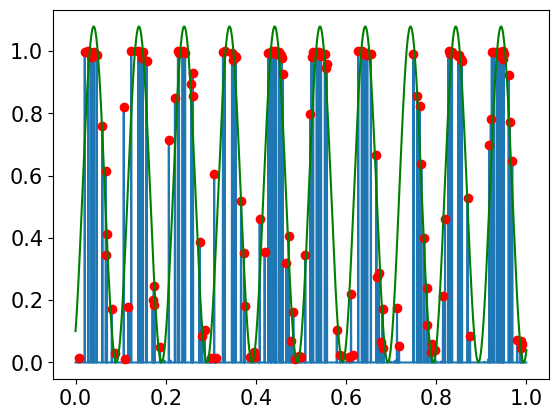

In [20]:

peaks_idx, _ = find_peaks(overlay_max_238, height=0.01)
peak_vals = overlay_max_238[peaks_idx]
def sine_func(x, A, freq, phase, offset):
    return A * np.sin(2 * np.pi * freq * x + phase) + offset

A0 = (peak_vals.max() - peak_vals.min()) / 2
offset0 = peak_vals.mean()
freq0 = 1 / int(100/dt)  # guess one cycle across the window
phase0 = 0

fs = int(1000/dt)  # samples per second
t = peaks_idx / fs

popt_238, _ = curve_fit(
    sine_func, t, peak_vals,
    p0=[A0, 1/(int(100/dt)/fs), phase0, offset0],
    maxfev=10000
)

x_fit_150 = np.linspace(0, int(1000/dt)/fs, 1000)
plt.plot(np.arange(len(overlay_max_238))/fs, overlay_max_238, label="overlay_mean")
plt.plot(t, peak_vals, 'ro', label="peaks")
plt.plot(x_fit_150, sine_func(x_fit_150, *popt_238), 'g-', label="sine fit")

In [21]:
popt_238

array([ 0.53902194,  9.96244104, -0.95067368,  0.53931208])

In [22]:
midpoint, vertices_cortex, neural_masses, n_mass, distance_matrix, results, wo, wa, wc, wr, wr_local = PWstim.create_cortical_surface(V1_area, distance_between_masses, distance_coef, sigma_s, nResponses, nLayers, ntheta, nt, coef_opo, coef_att, go, ga, gc, gr)
pRFs,visual_field_pos_neural_masses, eccentricity, radii = PWstim.make_PRFs(neural_masses, midpoint, stimulus_size, n_mass)

In [23]:
inpu = PWstim._compute_input_attentional(nt, pRFs, frames, dt)
dot_input = 0.5
n_phases = 300
period_steps = int((1 / temporal_frequency) / (dt/1000)) 
phase_offsets = np.linspace(0, period_steps, n_phases, endpoint=False).astype(int)

t = 0
phase_idx = 0
position_2 = [148, 157, 166, 175, 184, 193, 202, 211, 220, 180, 181, 182, 183, 185, 186, 187, 188]
while t < int(T/dt):
    inpu[position_2, t:t+13] = dot_input
    step = 200 + phase_offsets[phase_idx % n_phases] 
    t += step
    phase_idx += 1

In [24]:
inpu_bino = np.zeros((n_mass, 2, 2, nt))
inpu_bino[:, 0, 0, :] = inpu
inpu_bino[:, 1, 0, :] = inpu
inpu_bino = inpu_bino.astype('float32')

In [25]:
results_attentional_waves=BWOrganics.run_simulation( 
nt, 
n_mass,
dt,
ntheta,
n_m,
n,
sigma,
m,
wh,
tau_v1,
tau_attention,
tau_adaptation,
tau_opponency,
tau_recurrence,
tau_binocular,
sigma_a,
aKernel,
results, 
wo, 
wa,
inpu_bino,
wc,
wr,
wr_local,
W_rr,
b_0,
c_attention,
distance_matrix,
ms_per_neuron)

In [26]:
results_mean = np.mean(results_attentional_waves[position_2, 3, 6, 0, :], axis = 0)

In [27]:
peaks_idx, _ = find_peaks(results_mean)
response_peaks = np.zeros_like(results_mean)
response_peaks[peaks_idx] =results_mean[peaks_idx]

amplitude = response_peaks.max() - response_peaks.min()

std_noise = 0.02 * amplitude

threshold = threshold_from_percentile(response_peaks, std_noise, 50)

hitrates_over_time_202 = np.zeros_like(response_peaks)
for t in range(len(response_peaks)):
    hitrates_over_time_202[t] = get_hit_rate(response_peaks[t], threshold, std_noise)

In [28]:
window_size = 2000
n_windows = len(hitrates_over_time_202) // window_size 

# Reshape into (n_windows, window_size)
windows = hitrates_over_time_202[: n_windows*window_size].reshape(n_windows, window_size)

# Overlay: keep max (or sum, or mean) at each position
overlay_max_202 = windows.max(axis=0)

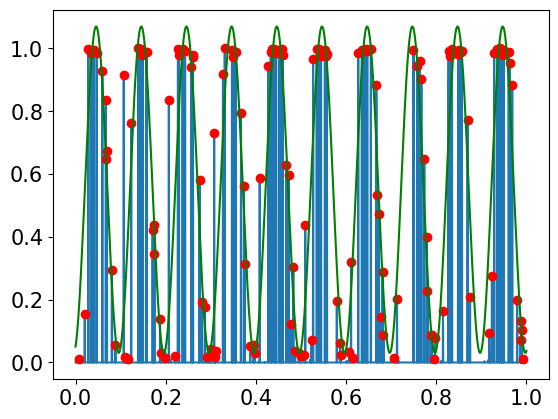

In [29]:

peaks_idx, _ = find_peaks(overlay_max_202, height=0.01)
peak_vals = overlay_max_202[peaks_idx]
def sine_func(x, A, freq, phase, offset):
    return A * np.sin(2 * np.pi * freq * x + phase) + offset

A0 = (peak_vals.max() - peak_vals.min()) / 2
offset0 = peak_vals.mean()
freq0 = 1 / int(100/dt)   # guess one cycle across the window
phase0 = 0

fs = int(1000/dt)  # samples per second
t = peaks_idx / fs

popt_202, _ = curve_fit(
    sine_func, t, peak_vals,
    p0=[A0, 1/(int(100/dt)/fs), phase0, offset0],
    maxfev=10000
)

x_fit_202 = np.linspace(0, int(1000/dt)/fs, 1000)
plt.plot(np.arange(len(overlay_max_202))/fs, overlay_max_202, label="overlay_mean")
plt.plot(t, peak_vals, 'ro', label="peaks")
plt.plot(x_fit_150, sine_func(x_fit_202, *popt_202), 'g-', label="sine fit")

In [30]:
midpoint, vertices_cortex, neural_masses, n_mass, distance_matrix, results, wo, wa, wc, wr, wr_local = PWstim.create_cortical_surface(V1_area, distance_between_masses, distance_coef, sigma_s, nResponses, nLayers, ntheta, nt, coef_opo, coef_att, go, ga, gc, gr)
pRFs,visual_field_pos_neural_masses, eccentricity, radii = PWstim.make_PRFs(neural_masses, midpoint, stimulus_size, n_mass)

In [31]:
inpu = PWstim._compute_input_attentional(nt, pRFs, frames, dt)
dot_input = 0.5
n_phases = 300
period_steps = int((1 / temporal_frequency) / (dt/1000)) 
phase_offsets = np.linspace(0, period_steps, n_phases, endpoint=False).astype(int)

t = 0
phase_idx = 0
position_3 = [4, 13, 22, 31, 40, 49, 58, 67, 76, 36, 37, 38, 39, 41, 42, 43, 44]
while t < int(T/dt):
    inpu[position_3, t:t+13] = dot_input
    step = 200 + phase_offsets[phase_idx % n_phases] 
    t += step
    phase_idx += 1

In [32]:
inpu_bino = np.zeros((n_mass, 2, 2, nt))
inpu_bino[:, 0, 0, :] = inpu
inpu_bino[:, 1, 0, :] = inpu
inpu_bino = inpu_bino.astype('float32')

In [33]:
results_attentional_waves=BWOrganics.run_simulation( 
nt, 
n_mass,
dt,
ntheta,
n_m,
n,
sigma,
m,
wh,
tau_v1,
tau_attention,
tau_adaptation,
tau_opponency,
tau_recurrence,
tau_binocular,
sigma_a,
aKernel,
results, 
wo, 
wa,
inpu_bino,
wc,
wr,
wr_local,
W_rr,
b_0,
c_attention,
distance_matrix,
ms_per_neuron)

In [34]:
results_mean = np.mean(results_attentional_waves[position_3, 3, 6, 0, :], axis = 0)

In [35]:
peaks_idx, _ = find_peaks(results_mean)
response_peaks = np.zeros_like(results_mean)
response_peaks[peaks_idx] =results_mean[peaks_idx]

amplitude = response_peaks.max() - response_peaks.min()

std_noise = 0.02 * amplitude

threshold = threshold_from_percentile(response_peaks, std_noise, 50)

hitrates_over_time_166 = np.zeros_like(response_peaks)
for t in range(len(response_peaks)):
    hitrates_over_time_166[t] = get_hit_rate(response_peaks[t], threshold, std_noise)

In [36]:
window_size = 2000
n_windows = len(hitrates_over_time_166) // window_size 

# Reshape into (n_windows, window_size)
windows = hitrates_over_time_166[: n_windows*window_size].reshape(n_windows, window_size)

# Overlay: keep max (or sum, or mean) at each position
overlay_max_166 = windows.max(axis=0)

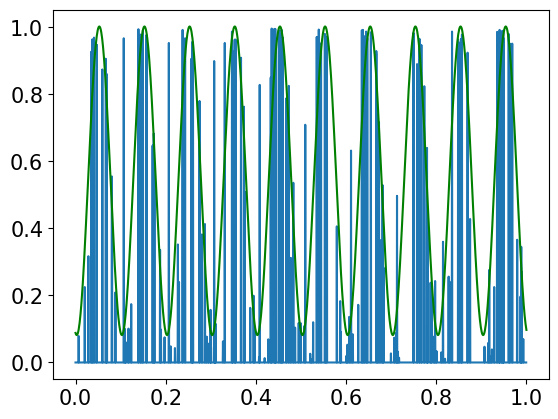

In [37]:

peaks_idx, _ = find_peaks(overlay_max_166, height=0.01)
peak_vals = overlay_max_166[peaks_idx]
def sine_func(x, A, freq, phase, offset):
    return A * np.sin(2 * np.pi * freq * x + phase) + offset

A0 = (peak_vals.max() - peak_vals.min()) / 2
offset0 = peak_vals.mean()
freq0 = 1 / int(100/dt)   # guess one cycle across the window
phase0 = 0

fs = int(1000/dt)  # samples per second
t = peaks_idx / fs

popt_166, _ = curve_fit(
    sine_func, t, peak_vals,
    p0=[A0, 1/(int(100/dt)/fs), phase0, offset0],
    maxfev=10000
)

x_fit_202 = np.linspace(0, int(1000/dt)/fs, 1000)
plt.plot(np.arange(len(overlay_max_166))/fs, overlay_max_166, label="overlay_mean")
# plt.plot(t, peak_vals, 'ro', label="peaks")
plt.plot(x_fit_150, sine_func(x_fit_202, *popt_166), 'g-', label="sine fit")

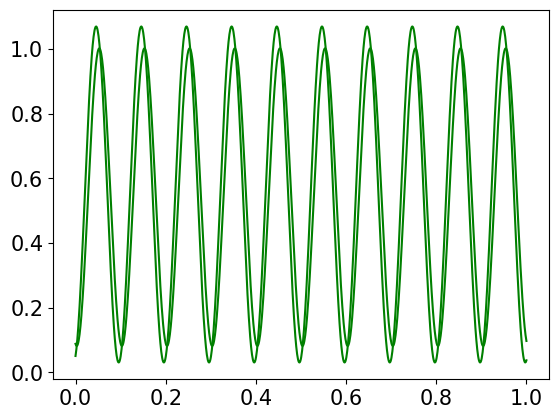

In [38]:
plt.plot(x_fit_150, sine_func(x_fit_202, *popt_202), 'g-', label="sine fit")
plt.plot(x_fit_150, sine_func(x_fit_202, *popt_166), 'g-', label="sine fit")

In [39]:
delta_phase = (popt_166[2] - popt_238[2]) 
w = 2*np.pi* temporal_frequency
delta_t = delta_phase / w 
print(delta_t)
print(delta_phase * 180/ np.pi)
print(popt_202[1])

-0.01253899201679341
-45.14037126045628
9.981111694307586


In [40]:
popt_real = np.array([0.5, 10, 0, 0.5])

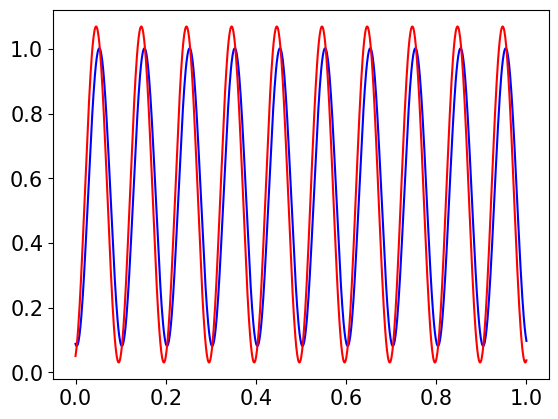

In [41]:
# plt.plot(x_fit_150, sine_func(x_fit_202, *popt_real), 'g-', label="sine fit")
plt.plot(x_fit_150, sine_func(x_fit_202, *popt_166), 'b-', label="sine fit")
plt.plot(x_fit_150, sine_func(x_fit_202, *popt_202), 'r-', label="sine fit")

In [45]:
def get_phase(x, freq, phase):
    value = 2 * np.pi * freq * x + phase
    angle = value - ((value // (2*np.pi)) * 2*np.pi)

    angle = angle * 180 / np.pi
    return angle

In [46]:
x_fit_test = np.linspace(0, int(100/dt)/fs, 1000)

In [47]:
x_values = get_phase(x_fit_test, 10, np.pi/2)
y_values_1 = sine_func(x_fit_test, *popt_238)
y_values_2 = sine_func(x_fit_test, *popt_202)
y_values_3 = sine_func(x_fit_test, *popt_166)

In [66]:


shifted = ((x_values -45 + 180) % 360) - 180 

order = np.argsort(shifted)
shifted_sorted = shifted[order]
hitrate_sorted_1 = y_values_1[order]
hitrate_sorted_2 = y_values_2[order]
hitrate_sorted_3 = y_values_3[order]


In [76]:
shifted_sorted[np.argmax(hitrate_sorted_3)] +360

np.float64(234.90990990990997)

/tmp/ipykernel_33976/3493165270.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


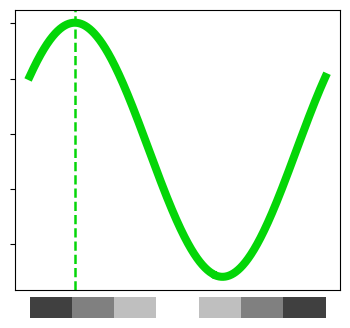

In [71]:
from matplotlib.gridspec import GridSpec
fig = plt.figure(figsize=(4.2, 4))
gs = GridSpec(2, 1, height_ratios=[8, 0.6], hspace=0.05)  # main plot much taller than the strip

ax = fig.add_subplot(gs[0])                # your normal plot
ax_bins = fig.add_subplot(gs[1], sharex=ax) 
ax.plot(shifted_sorted, hitrate_sorted_3, color = '#04D608', linewidth = 5.8)
# ax.plot(shifted_sorted, hitrate_sorted_2/1.7, color = '#00FFF7', linewidth = 5.8)
# ax.plot(shifted_sorted, hitrate_sorted_1, color = 'blue', linewidth = 5.8)


# relabel ticks back to real phase values (mod 360)
# tick_positions = np.arange(-180, 181, 30)
# tick_labels = [(t+90) % 360 for t in tick_positions]
# ax.set_xticks(tick_positions)
# ax.set_xticklabels(tick_labels)
ax.set_xticklabels([])
ax.set_yticklabels([])



 # thin strip, same x-range

# alternate two greys across N equal bins
n_bins = 7
edges = np.linspace(-180, 180, n_bins + 1)
colors = ["0.25", "0.5", "0.75", '1', "0.75", "0.5", "0.25"] * (n_bins + 1)   # dark/light grey, repeating

for i in range(n_bins):
    ax_bins.axvspan(edges[i], edges[i+1], color=colors[i], lw=0)

ax_bins.set_yticks([])
ax_bins.set_xticks([])          # main ax keeps the tick labels (270°/90°/270°)
for s in ax_bins.spines.values():
    s.set_visible(False)

# ax.set_xlabel("Phase")
# ax.set_ylabel("Hitrate")
# ax.axvline(shifted_sorted[np.argmax(hitrate_sorted_1)], color='blue', linestyle='--', linewidth=1.8) 
# ax.axvline(shifted_sorted[np.argmax(hitrate_sorted_2)], color='#00FFF7', linestyle='--', linewidth=1.8) 
ax.axvline(shifted_sorted[np.argmax(hitrate_sorted_3)], color='#04D608', linestyle='--', linewidth=1.8)
# ax.axvline(shifted_sorted[962], color='blue', linestyle='--', linewidth=0.8)  # marks 90 at center
plt.tight_layout()
# plt.legend()
plt.show()

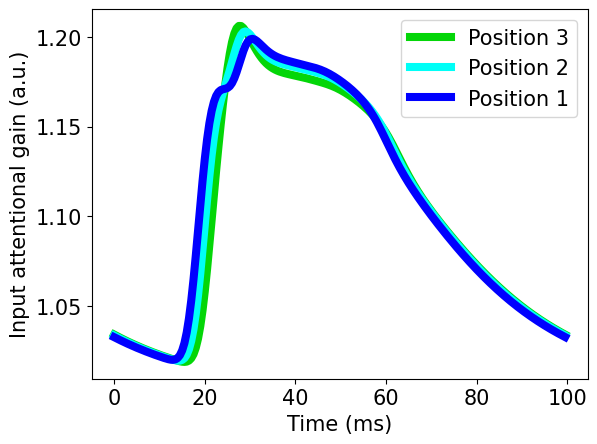

In [78]:
fig, ax = plt.subplots()
tick_positions = np.arange(0, 100, 0.5)
ax.plot(tick_positions,results_attentional_waves[166, 3, 2, 0, 2000:2200], label = 'Position 3', color = '#04D608', linewidth = 5.8)
ax.plot(tick_positions,results_attentional_waves[202, 3, 2, 0, 2000:2200],  label = 'Position 2', color = '#00FFF7', linewidth = 5.8)
ax.plot(tick_positions,results_attentional_waves[238, 3, 2, 0, 2000:2200],   label = 'Position 1', color = 'blue', linewidth = 5.8)



ax.set_xlabel('Time (ms)')
ax.set_ylabel('Input attentional gain (a.u.)')

ax.legend()